In [84]:
from ollama import chat
from ollama import ChatResponse
import pandas as pd
import numpy as np
import os
import json

In [12]:
response: ChatResponse = chat(model='llama3.2:3b', messages=[
  {
    'role': 'user',
    'content': 'Why is the sky blue?',
  },
])
print(response['message']['content'])

The sky appears blue because of a phenomenon called Rayleigh scattering, named after the British physicist Lord Rayleigh. He discovered that when sunlight enters Earth's atmosphere, it encounters tiny molecules of gases such as nitrogen and oxygen.

Here's what happens:

1. **Sunlight enters the atmosphere**: When sunlight enters the atmosphere, it is made up of different colors (wavelengths) that are all traveling in the same direction.
2. **Scattering occurs**: The tiny molecules in the air scatter the light in all directions. However, they scatter shorter (blue) wavelengths more than longer (red) wavelengths.
3. **Blue light is scattered in all directions**: As a result, blue light is scattered into every part of the atmosphere, making it visible from any angle. This is why the sky appears blue during the day when the sun is overhead.
4. **Red light continues straight**: The longer wavelengths of red light are not scattered as much and continue to travel in a more direct path, reach

In [ ]:
# --- APACHE II Scoring Functions (Simplified) ---
def score_temperature(temp):
    # Temperature in Celsius
    if temp < 30:
        return 4
    elif temp < 32:
        return 3
    elif temp < 34:
        return 2
    elif temp < 36:
        return 1
    elif temp <= 38.4:
        return 0
    elif temp < 39:
        return 0
    elif temp < 41:
        return 1
    elif temp < 42:
        return 2
    else:
        return 4

def score_map(map_val):
    if map_val < 40:
        return 4
    elif map_val < 70:
        return 2
    elif map_val <= 109:
        return 0
    elif map_val <= 129:
        return 2
    else:
        return 4

def score_hr(hr):
    if hr < 40:
        return 4
    elif hr < 55:
        return 3
    elif hr < 70:
        return 2
    elif hr <= 109:
        return 0
    elif hr < 140:
        return 2
    elif hr < 180:
        return 3
    else:
        return 4

def score_rr(rr):
    if rr < 6:
        return 4
    elif rr < 10:
        return 2
    elif rr <= 24:
        return 0
    elif rr <= 34:
        return 1
    elif rr <= 49:
        return 3
    else:
        return 4

def score_oxygenation(pao2, fiO2):
    # Use PaO2 thresholds if FiO2 <= 0.5, otherwise use a simplified PF ratio cutoff
    if fiO2 <= 0.5:
        if pao2 >= 70:
            return 0
        elif pao2 >= 61:
            return 2
        elif pao2 >= 55:
            return 3
        else:
            return 4
    else:
        pf = pao2 / fiO2 if fiO2 > 0 else 0
        if pf >= 200:
            return 0
        elif pf >= 150:
            return 2
        elif pf >= 100:
            return 3
        else:
            return 4

def score_ph(ph):
    # Using typical APACHE II cutoffs for arterial pH
    if ph >= 7.7:
        return 4
    elif ph >= 7.6:
        return 3
    elif ph >= 7.5:
        return 1
    elif ph >= 7.33:
        return 0
    elif ph >= 7.25:
        return 2
    elif ph >= 7.15:
        return 3
    else:
        return 4

def score_na(na):
    if na >= 180:
        return 4
    elif 160 <= na < 180:
        return 3
    elif 155 <= na < 160:
        return 2
    elif 150 <= na < 155:
        return 1
    elif 130 <= na < 150:
        return 0
    elif 120 <= na < 130:
        return 2
    elif 111 <= na < 120:
        return 3
    else:  # na < 111
        return 4

def score_k(k):
    if k >= 7:
        return 4
    elif 6 <= k < 7:
        return 3
    elif 5.5 <= k < 6:
        return 1
    elif 3.5 <= k < 5.5:
        return 0
    elif 3.0 <= k < 3.5:
        return 1
    elif 2.5 <= k < 3.0:
        return 2
    else:
        return 4

def score_creatinine(cr):
    if cr >= 3.5:
        return 4
    elif cr >= 2.0:
        return 3
    elif cr >= 1.5:
        return 2
    elif cr >= 0.6:
        return 0
    else:
        return 2

def score_hct(hct):
    if hct >= 60:
        return 4
    elif hct >= 50:
        return 2
    elif hct >= 46:
        return 1
    elif hct >= 30:
        return 0
    elif hct >= 20:
        return 2
    else:
        return 4

def score_wbc(wbc):
    if wbc >= 40:
        return 4
    elif wbc >= 20:
        return 2
    elif wbc >= 15:
        return 1
    elif wbc >= 3:
        return 0
    elif wbc >= 1:
        return 2
    else:
        return 4

def score_gcs(gcs):
    # In APACHE II, the GCS component is 15 - GCS, capped at a maximum of 13.
    return min(15 - gcs, 13)

def score_age(age):
    if age < 45:
        return 0
    elif age < 55:
        return 2
    elif age < 65:
        return 3
    elif age < 75:
        return 5
    else:
        return 6

def compute_apache2(row):
    temp_score = score_temperature(row['Temp'])
    map_score = score_map(row['MAP'])
    hr_score = score_hr(row['HR'])
    rr_score = score_rr(row['RespRate'])
    oxy_score = score_oxygenation(row['PaO2'], row['FiO2'])
    ph_score = score_ph(row['pH'])
    na_score = score_na(row['Na'])
    k_score = score_k(row['K'])
    cr_score = score_creatinine(row['Creatinine'])
    hct_score = score_hct(row['HCT'])
    wbc_score = score_wbc(row['WBC'])
    gcs_score = score_gcs(row['GCS'])
    age_score = score_age(row['Age'])
    
    # Note: Chronic Health Points are not available in this dataset.
    return (temp_score + map_score + hr_score + rr_score + oxy_score +
            ph_score + na_score + k_score + cr_score + hct_score +
            wbc_score + gcs_score + age_score)

# --- SOFA Scoring Functions (Simplified) ---
def score_sofa_respiratory(row):
    # Compute the PaO2/FiO2 ratio
    fiO2 = row['FiO2']
    pao2 = row['PaO2']
    pf = pao2 / fiO2 if fiO2 > 0 else 0
    # If patient is on mechanical ventilation (assumed MechVent==1), use the following thresholds:
    if row['MechVent'] == 1 or row['MechVent'] == 1.0:
        if pf >= 400:
            return 0
        elif pf >= 300:
            return 1
        elif pf >= 200:
            return 2
        elif pf >= 100:
            return 3
        else:
            return 4
    else:
        # If not ventilated, we use similar thresholds (this can be adjusted as needed)
        if pf >= 400:
            return 0
        elif pf >= 300:
            return 1
        elif pf >= 200:
            return 2
        elif pf >= 100:
            return 3
        else:
            return 4

def score_sofa_coagulation(platelets):
    if platelets >= 150:
        return 0
    elif platelets >= 100:
        return 1
    elif platelets >= 50:
        return 2
    elif platelets >= 20:
        return 3
    else:
        return 4

def score_sofa_liver(bilirubin):
    if bilirubin < 1.2:
        return 0
    elif bilirubin < 2.0:
        return 1
    elif bilirubin < 6.0:
        return 2
    elif bilirubin < 12.0:
        return 3
    else:
        return 4

def score_sofa_cardiovascular(map_val):
    # Simplified version: using only MAP (without vasopressor doses)
    return 0 if map_val >= 70 else 1

def score_sofa_cns(gcs):
    if gcs == 15:
        return 0
    elif gcs >= 13:
        return 1
    elif gcs >= 10:
        return 2
    elif gcs >= 6:
        return 3
    else:
        return 4

def score_sofa_renal(creatinine, urine):
    # Using creatinine thresholds; urine output could be used if available
    if creatinine < 1.2:
        return 0
    elif creatinine < 2.0:
        return 1
    elif creatinine < 3.5:
        return 2
    elif creatinine < 5.0:
        return 3
    else:
        return 4

def compute_sofa(row):
    resp = score_sofa_respiratory(row)
    coag = score_sofa_coagulation(row['Platelets'])
    liver = score_sofa_liver(row['Bilirubin'])
    cardio = score_sofa_cardiovascular(row['MAP'])
    cns = score_sofa_cns(row['GCS'])
    renal = score_sofa_renal(row['Creatinine'], row['Urine'])
    return resp + coag + liver + cardio + cns + renal

# --- Individual Derived Metrics ---
def compute_pf_ratio(row):
    return row['PaO2'] / row['FiO2'] if row['FiO2'] > 0 else None

def compute_shock_index(row):
    return row['HR'] / row['SysABP'] if row['SysABP'] > 0 else None

def compute_map_calc(row):
    # Recompute MAP from SysABP and DiasABP
    return (2 * row['DiasABP'] + row['SysABP']) / 3

def compute_oxygenation_index(row):
    # Oxygenation Index = (FiO2 * MAP * 100) / PaO2
    return (row['FiO2'] * row['MAP'] * 100) / row['PaO2'] if row['PaO2'] > 0 else None

def compute_bun_creatinine_ratio(row):
    return row['BUN'] / row['Creatinine'] if row['Creatinine'] > 0 else None


In [32]:
raw_val = pd.read_csv('dataframes/raw_val.csv')
raw_val.groupby('PatientID')
patientID = raw_val["PatientID"][0]
print(patientID)
filteredDF = raw_val[raw_val["PatientID"] == patientID]
filteredDF

142675


,PatientID,Hour,ALP,ALT,AST,Age,Albumin,BUN,Bilirubin,Cholesterol,...,RespRate,SaO2,SysABP,Temp,TroponinI,TroponinT,Urine,WBC,Weight,pH
0,142675,0.0,79.0,30.0,44.0,70.0,3.0,19.0,0.7,155.0,...,19.0,98.0,117.0,37.0,2.0,0.13,80.0,11.4,85.0,7.50
1,142675,1.0,79.0,30.0,44.0,70.0,3.0,19.0,0.7,155.0,...,19.0,98.0,104.0,35.7,2.0,0.13,80.0,11.4,85.0,7.50
2,142675,2.0,79.0,30.0,44.0,70.0,3.0,13.0,0.7,155.0,...,19.0,98.0,147.0,35.8,2.0,0.13,300.0,11.4,85.0,7.50
3,142675,3.0,79.0,30.0,44.0,70.0,3.0,13.0,0.7,155.0,...,19.0,98.0,128.0,35.8,2.0,0.13,380.0,11.4,85.0,7.43
4,142675,4.0,79.0,30.0,44.0,70.0,3.0,13.0,0.7,155.0,...,19.0,98.0,0.0,33.4,2.0,0.13,200.0,11.4,85.0,7.36
5,142675,5.0,79.0,30.0,44.0,70.0,3.0,9.0,0.7,155.0,...,19.0,98.0,0.0,33.4,2.0,0.13,300.0,7.9,85.0,7.34
6,142675,6.0,79.0,30.0,44.0,70.0,3.0,9.0,0.7,155.0,...,19.0,98.0,0.0,33.4,2.0,0.13,300.0,7.9,85.0,7.42
7,142675,7.0,79.0,30.0,44.0,70.0,3.0,9.0,0.7,155.0,...,19.0,98.0,79.0,33.4,2.0,0.13,300.0,7.9,85.0,7.42
8,142675,8.0,24.0,30.0,44.0,70.0,1.7,12.0,0.9,155.0,...,19.0,98.0,0.0,34.6,2.0,0.13,300.0,8.7,85.0,7.45
9,142675,9.0,24.0,30.0,44.0,70.0,1.7,12.0,0.9,155.0,...,19.0,98.0,0.0,35.3,2.0,0.13,300.0,8.7,85.0,7.37


In [37]:
df = pd.DataFrame()
df['APACHE_II'] = filteredDF.apply(compute_apache2, axis=1)
df['SOFA'] = filteredDF.apply(compute_sofa, axis=1)
print(df['APACHE_II'].mean(), df['SOFA'].mean())

22.897959183673468 9.306122448979592


In [ ]:
aggragatedDF = pd.DataFrame()
aggragatedDF['APACHE_II'] = raw_val.groupby('PatientID').apply(lambda x: compute_apache2(x.iloc[0]))
aggragatedDF['SOFA'] = raw_val.groupby('PatientID').apply(lambda x: compute_sofa(x.iloc[0]))
deathDF = pd.DataFrame(columns=['PatientID', 'Death'])

batch_size = 1
for i in range(0, 50, batch_size):
    batch = aggragatedDF.iloc[i:i+batch_size]
    prompt = "Will the following patients die in the next 48 hours given the following metrics? Respond with '1' if he died or '0' if not for each patient. RESPOND WITH A BINARY ARRAY! GIVE ME JUST THE ARRAY\n"
    for row in batch.iterrows():
        prompt += f"Patient {row[0]}: APACHE II {row[1]['APACHE_II']}, SOFA {row[1]['SOFA']}\n"
    response = chat(model='llama3.2:3b', messages=[
    {
        'role': 'user',
        'content': prompt,
    },
    ])
    results = json.loads(response['message']['content'])
    print(results)
    batch_ids = batch.index.to_list()
    batch_results = pd.DataFrame({'PatientID': batch_ids, 'Death': results})

    deathDF = pd.concat([deathDF, batch_results], ignore_index=True)

/var/folders/kx/45_n67vs6_z3s8j5019ns3qw0000gn/T/ipykernel_2501/3111707199.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggragatedDF['APACHE_II'] = raw_val.groupby('PatientID').apply(lambda x: compute_apache2(x.iloc[0]))
/var/folders/kx/45_n67vs6_z3s8j5019ns3qw0000gn/T/ipykernel_2501/3111707199.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggragatedDF['SOFA'] = raw_val.groupby('PatientID').app

[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[1]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[1]
[0]
[0]
[0]
[0]
[0]
[0]
[1]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]


,PatientID,Death
0,142675,0
1,142676,0
2,142680,0
3,142683,0
4,142688,0
5,142690,0
6,142691,0
7,142692,0
8,142693,0
9,142694,0


   RecordID  SAPS-I  SOFA  Length_of_stay  Survival  In-hospital_death
0    142675      27    14               9         7                  1
1    142676      12     1              31       468                  0


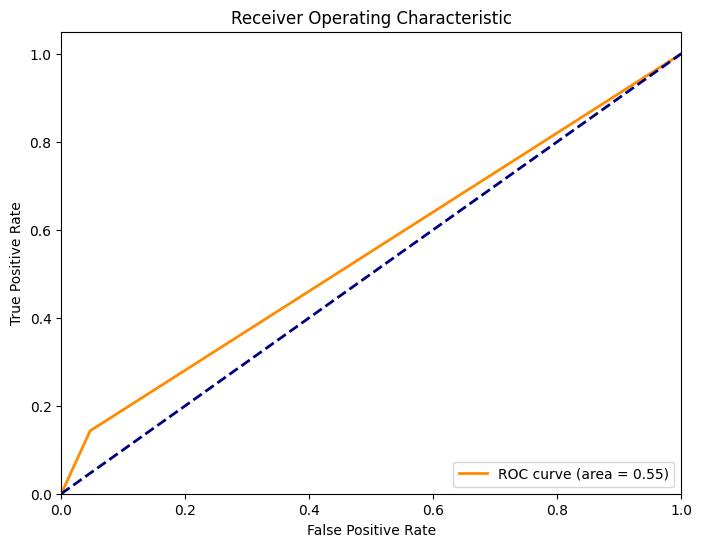

In [100]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

targetDeath = pd.read_csv('ml4h_data/p1/Outcomes-b.txt')
print(targetDeath.head(2))
targetDeath = targetDeath[['RecordID', 'In-hospital_death']]
targetDeath.columns = ['PatientID', 'Death']

mergedDF = pd.merge(deathDF, targetDeath, on='PatientID', suffixes=('_pred', '_true'))
y_true = mergedDF['Death_true']
y_score = mergedDF['Death_pred']

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()